## AI4Climate ML tutorial - Data Exploration
* Author: Stephen Haddad and Kate Brown.
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered


![climate_zones](https://upload.wikimedia.org/wikipedia/commons/thumb/3/32/K%C3%B6ppen-Geiger_Climate_Classification_Map_%281980%E2%80%932016%29_no_borders.png/1920px-K%C3%B6ppen-Geiger_Climate_Classification_Map_%281980%E2%80%932016%29_no_borders.png) 
The climate of different areas of the world is classified into different types, based on the Koppen-Geiger scheme. As the climate changes, some areas may change the classification of their climate 
In this series of tutorial notebooks, we willlearn how to build a machine learning pipeline by building a model to predict the clinate zone of a location from key climate means and indicators. We will look at how climate models predict shifts in the classification of climate zones as the climate changes in the future.

Links
 - [Climate Zones- Wikipedia](https://en.wikipedia.org/wiki/K%C3%B6ppen_climate_classification)
 - [Climate Zones Dataset](https://www.gloh2o.org/koppen/#:~:text=The%20K%C3%B6ppen%2DGeiger%20climate%20classification%20maps%20are%20high%2Dresolution,Climate%20Sensitivity%20(ECS)%2C%20and%20historical%20warming%20trend) 
    

### Prerequisites 

To be able to sucessfully work through this notebook, you will need some understanding of the following
- The python programming language
- Simple data handling in python
- Basic plotting using matplotlib
- Environment set up using pip or conda

### Learning outcomes from completing the notebook
* Loading and exploring tabular and gridded data using pandas
* Typical techniques for exploratory data analysis on different sorts of data
* Key characteristics of datasets to use in choosing components for a machine learning pipeline

## Tutorial - Exploratory Data Analysis
The first step in a machine learning problem is to understand the data you have available for training a machine learning algorithm. In any data driven technique, the quality of the results is only going to be as good as the quality of the data. Different machine learning techniques are appropriate to the different types of dat that you might have, so understanding the dataset to be used is the foundation of a successful outcome.

To do this yopu would usually start with **Exploratory Data Analysis (EDA)**. This involves creating summary statistics and visualisations that bring out the key characteristics of ther dataset's feature relevant to your problem. A feature in machine learning is an input variable - a set of data that give to a model so that it can learn patterns and make predictions. 

Some important aspect to consider during EDA include:
- The range of values different input feature can take e.g. min and max temperature, start and end dates.
- Important subsets of the data e.g. different seasons or time of the day.
- Distributions of different features, both as a whole and important subsets
- Correlations between different features, especially input and target features.


### Dataset 1 - Climate Zones

The first dataset we will be looking at is a **tabular dataset** which groups together land points on the earth with similar climate zones. Tabular dataset is one where the rows of the table represent different data points, for example observation at different times or different locations. The columns represent different attributes of the data point. This can include metadata such as the time and location for the collection of the data (for example an observed temperature measurement), or for which the data applies (for example a weather forecast). 

In this example each row in our dataset will represent a particular land point for a particular climate time period. The different columns represent different **features**. Features in this data set features include:
* location specified by latitude and longitude
* climate period
* scenario - either `historical` for past climate periods, or a [*shared socioeconomic pathway* or *SSP*](https://en.wikipedia.org/wiki/Shared_Socioeconomic_Pathways) for future periods based on climate projection.
* monthly means and standard deviations of temperature and precipitation  for each month of the year, averaged for the climate period.  

The original dataset stores the data in a different way, as a **gridded dataset**. Gridded data is where the data is not simply rows and columns (2-dimensional), and different axes represent different dimensions of the data. Typically this will at a minimum be latitude and longitude, and usually a time axis. In addition you might have data representing vertical levels of the atmosphere on another axis. This format is less common generally but is widely used for geospatial data such as used in earth sciences, including weather and climate research. Different features which are columns in the tabular data are often separate multi-dimensional arrays in gridded format.



### Import of libraries
In this tutorial we will use some standard python libraries for weather and climate research. In addtion to base python libraries we are using:
- matplotlib for plotting
- cartopy for handling projections of the data for plotting
- pandas for loading and manipulating tabular data
- xarray for loading and manipulating gridded data. 

In [1]:
import pathlib
import os
import json

In [2]:
import matplotlib.pyplot
import cartopy.crs

In [3]:
import xarray
import pandas

### Define data access parameters
To load and analyse the dataset, we must fist specify the parameters that will help us select and access  the relevant portions of the data we wish to examine.

All key metadata defnitions have been consolidated into a single JSON configuration file; this ensures consistent definitions that are used in the notebooks in this tutorial.

In [4]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/ssde/j25b/ai4climate/data'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer, very 

In [5]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'climate_zones'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'climate_zones'
    return root_path


In [6]:
current_platform = tutorial_config['platform']
current_platform

'jasmin'

In [7]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/ssde/j25b/ai4climate/data/climate_zones')

In [8]:
ml_ready_dir = root_data_dir / 'ml_ready'
print(ml_ready_dir.is_dir())
ml_ready_dir

True


PosixPath('/gws/ssde/j25b/ai4climate/data/climate_zones/ml_ready')

In [9]:
resolutions_dict = {float(k1): v1 for k1,v1 in tutorial_config['resolutions_names'].items()}

dataset_prefix_dict = tutorial_config['dataset_prefix']

format_str = 'nc'
historic_scenario_str = 'historic'

future_scenario_list = tutorial_config['future_scenarios']
historic_scenario_list = tutorial_config['historic_scenarios']

time_periods = { 
    (1901,1930): historic_scenario_list, 
    (1931,1960): historic_scenario_list,
    (1961,1990): historic_scenario_list,
    (1991,2020): historic_scenario_list,
    (2041,2070): future_scenario_list,
    (2071,2099): future_scenario_list,
}


In [10]:
time_periods

{(1901, 1930): ['historic'],
 (1931, 1960): ['historic'],
 (1961, 1990): ['historic'],
 (1991, 2020): ['historic'],
 (2041, 2070): ['ssp119',
  'ssp126',
  'ssp245',
  'ssp370',
  'ssp434',
  'ssp460',
  'ssp585'],
 (2071, 2099): ['ssp119',
  'ssp126',
  'ssp245',
  'ssp370',
  'ssp434',
  'ssp460',
  'ssp585']}

In [11]:
fname_template = tutorial_config['fname_template']
time_dir_template = tutorial_config['time_dir_template']
period_scenario_template = 'climate_zones_{start}_{end}_{scenario}_{res}.csv'
ml_ready_fname_template =  tutorial_config['csv_out_template']

In [12]:
current_res = 1.0

In [13]:
climate_subgroups_dict = tutorial_config['climate_subgroups']#
climate_subgroups_dict

{'non-land': 'None',
 'Af': 'Tropical, rainforest',
 'Am': 'Tropical, monsoon',
 'Aw': 'Tropical, savannah',
 'BWh': 'Arid, desert, hot',
 'BWk': 'Arid, desert, cold',
 'BSh': 'Arid, steppe, hot',
 'BSk': 'Arid, steppe, cold',
 'Csa': 'Temperate, dry summer, hot summer',
 'Csb': 'Temperate, dry summer, warm summer',
 'Csc': 'Temperate, dry summer, cold summer',
 'Cwa': 'Temperate, dry winter, hot summer',
 'Cwb': 'Temperate, dry winter, warm summer',
 'Cwc': 'Temperate, dry winter, cold summer',
 'Cfa': 'Temperate, no dry season, hot summer',
 'Cfb': 'Temperate, no dry season, warm summer',
 'Cfc': 'Temperate, no dry season, cold summer',
 'Dsa': 'Cold, dry summer, hot summer',
 'Dsb': 'Cold, dry summer, warm summer',
 'Dsc': 'Cold, dry summer, cold summer',
 'Dsd': 'Cold, dry summer, very cold winter',
 'Dwa': 'Cold, dry winter, hot summer',
 'Dwb': 'Cold, dry winter, warm summer',
 'Dwc': 'Cold, dry winter, cold summer',
 'Dwd': 'Cold, dry winter, very cold winter',
 'Dfa': 'Cold, no

In [14]:
climate_subgroup_lookup = [k1 for k1 in climate_subgroups_dict.keys()]

In [15]:
climate_subgroup_lookup

['non-land',
 'Af',
 'Am',
 'Aw',
 'BWh',
 'BWk',
 'BSh',
 'BSk',
 'Csa',
 'Csb',
 'Csc',
 'Cwa',
 'Cwb',
 'Cwc',
 'Cfa',
 'Cfb',
 'Cfc',
 'Dsa',
 'Dsb',
 'Dsc',
 'Dsd',
 'Dwa',
 'Dwb',
 'Dwc',
 'Dwd',
 'Dfa',
 'Dfb',
 'Dfc',
 'Dfd',
 'ET',
 'EF']

In [16]:
climate_group_lookup = [k1[0] for k1 in climate_subgroups_dict.keys()]
climate_group_lookup[0] = 'none'
climate_group_lookup

['none',
 'A',
 'A',
 'A',
 'B',
 'B',
 'B',
 'B',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'E',
 'E']

### Load the data
We will now load data for historic and future periods in order to understand how the distributions change and use this to inform our model training.
We will start by loading the gridded data and exploring that, before we look at the processed machine-learning (ML) ready data which we will use for training a machine learning model.

In [17]:
def get_data_path(root_dir, time_period, scenario_id, prefix, resolution_str, suffix) :
    start_year = time_period[0]
    end_year = time_period[1]
    if scenario_id == historic_scenario_str:
        data_dir = root_data_dir / time_dir_template.format(start_year=start_year,end_year=end_year)
    else:
        data_dir = root_data_dir / time_dir_template.format(start_year=start_year,end_year=end_year) / scenario_id 
    data_fname = fname_template.format(prefix=prefix, 
                                       res=resolution_str, 
                                       suffix=format_str)
    return data_dir / data_fname

In [18]:
data_path_dict = {
    (start_year, end_year): {
        scenario_id: { ds_id: { current_res: get_data_path(root_dir=root_data_dir,
                                                           time_period=(start_year, end_year),
                                                           scenario_id=scenario_id, 
                                                           prefix=ds_str,
                                                           resolution_str=res_str,
                                                           suffix=format_str,
                                                          )
                                for current_res, res_str in resolutions_dict.items() 
                              }
                       for ds_id, ds_str in dataset_prefix_dict.items()
                     } 
        for scenario_id in current_scenarios
    }
    for (start_year, end_year), current_scenarios in time_periods.items()                                                                                                             
}

In [19]:
data_path_dict.keys()

dict_keys([(1901, 1930), (1931, 1960), (1961, 1990), (1991, 2020), (2041, 2070), (2071, 2099)])

In [20]:
data_path_dict[(1901,1930)].keys()

dict_keys(['historic'])

In [21]:
data_path_dict[(2071,2099)].keys()

dict_keys(['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp585'])

In [22]:
data_path_dict[(1901,1930)]['historic'].keys()

dict_keys(['climate_mean', 'climate_std', 'climate_zone'])

In [23]:
data_path_dict[(1901,1930)]['historic']['climate_mean'].keys()

dict_keys([0.1, 0.5, 1.0])

In [24]:
data_path_dict[(1901,1930)]['historic']['climate_mean'][0.1]

PosixPath('/gws/ssde/j25b/ai4climate/data/climate_zones/1901_1930/ensemble_mean_0p1.nc')

In [25]:
select_historic = (1901,1930)
select_future = (2071,2099)
select_future_scenario = 'ssp370'

In [26]:
data_dict = {
    current_period: {
        scenario_id: {ds_id: xarray.open_dataset(res_path_dict[1.0]) for ds_id, res_path_dict in ds_dict.items()} for scenario_id, ds_dict in data_path_dict[current_period].items()
    } for current_period in [select_historic, select_future]
}

Text(0.5, 1.0, 'KG Climate Zones diff (2071, 2099) compared to (1901, 1930)')

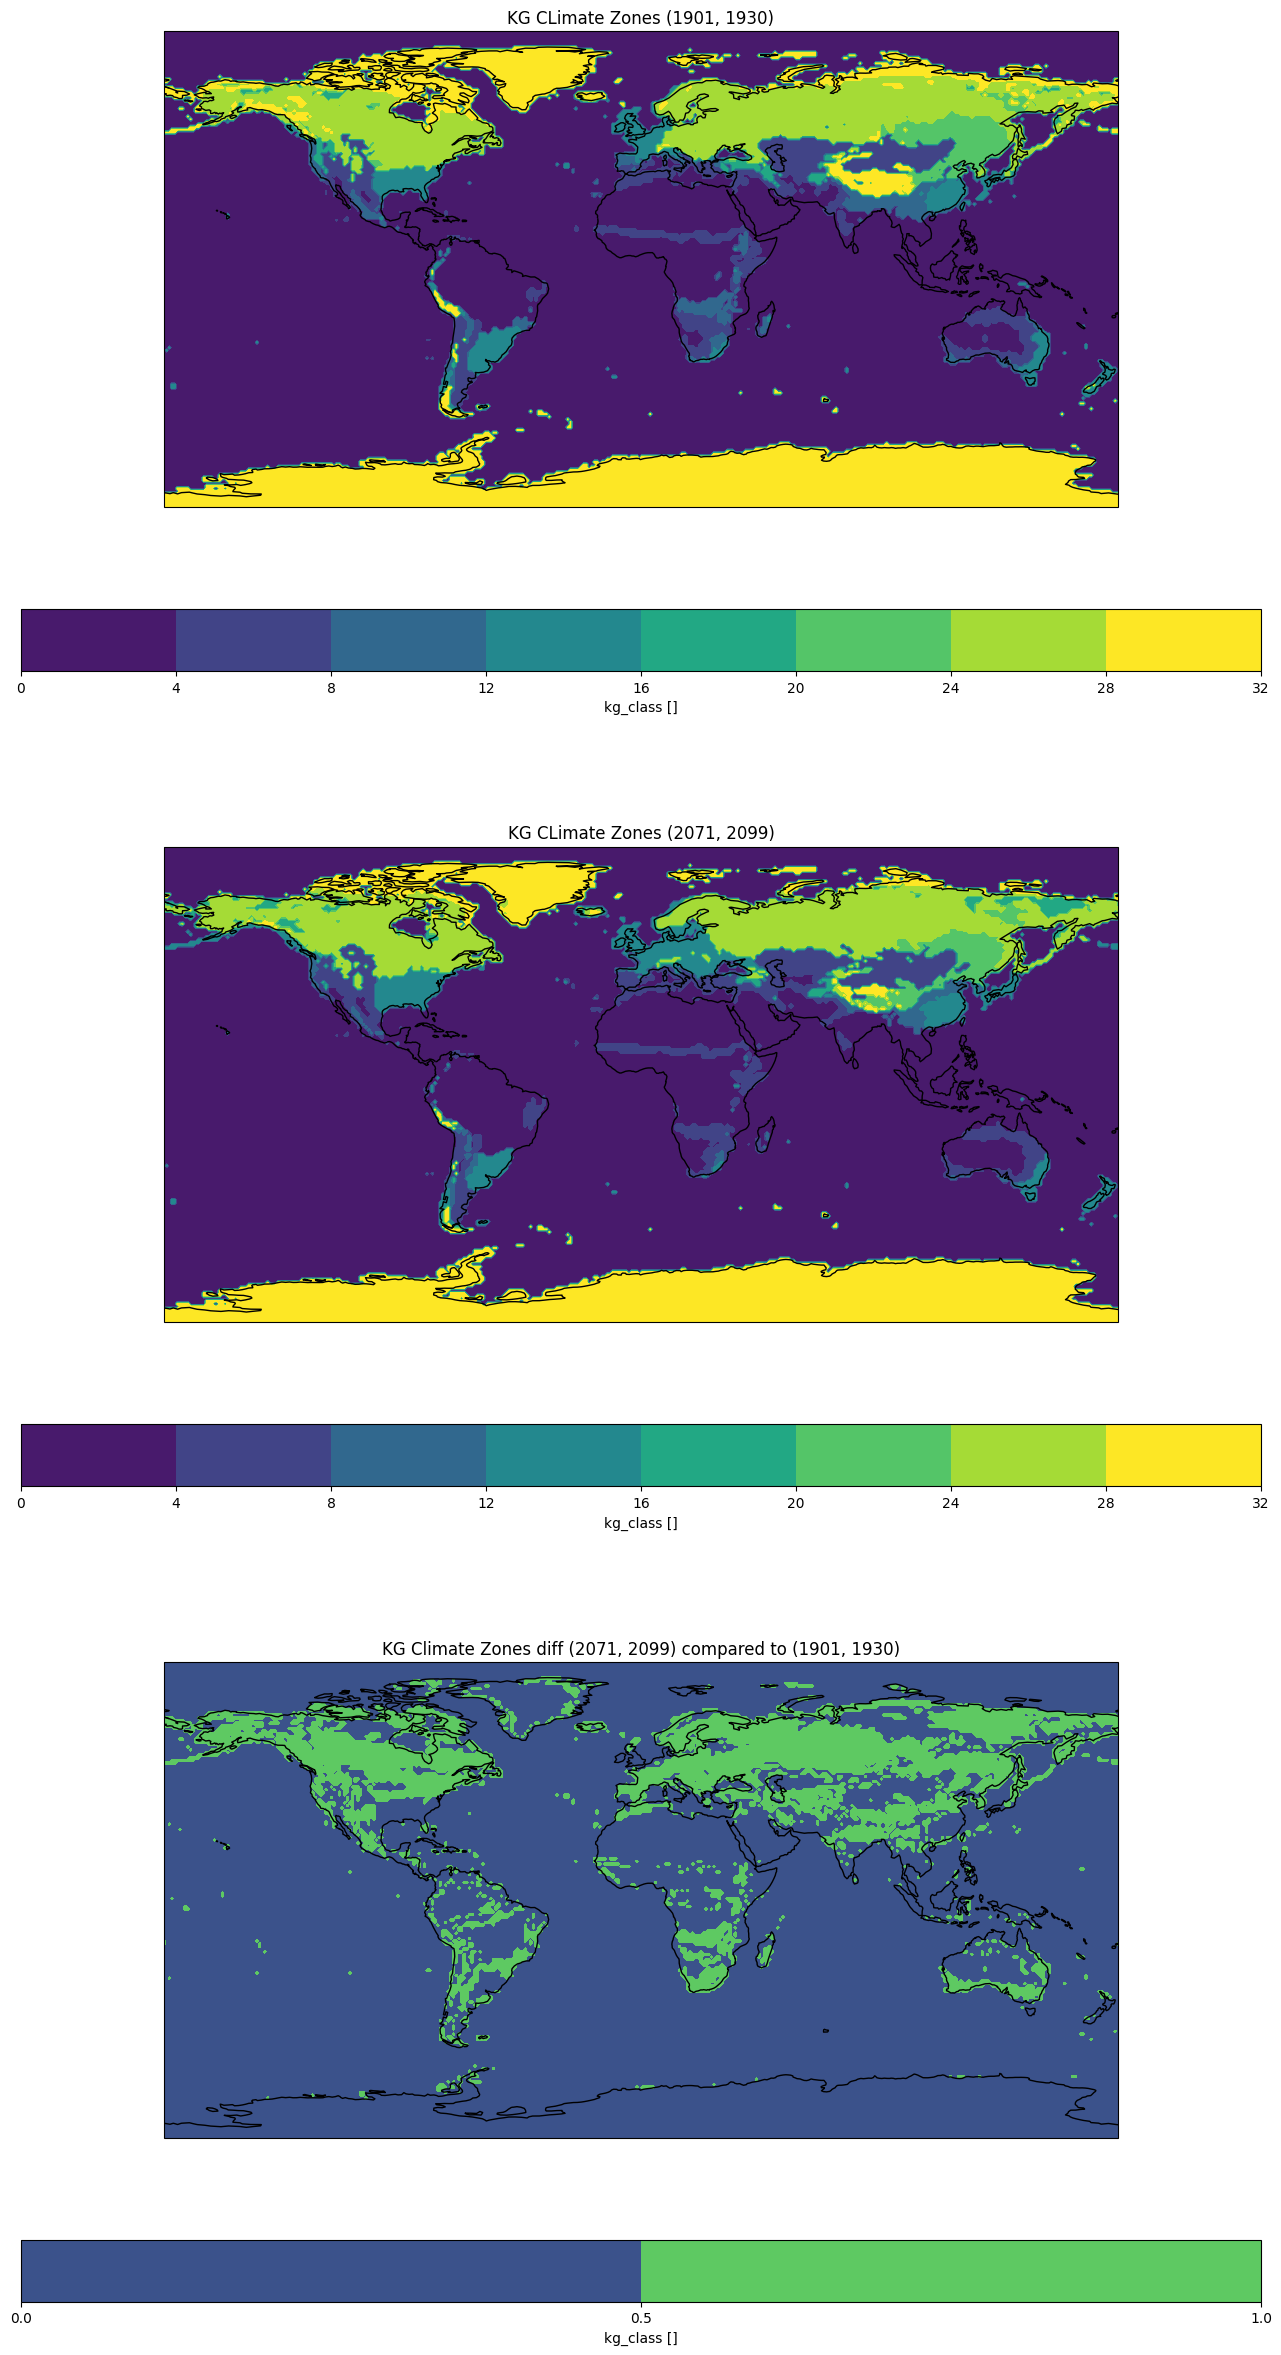

In [27]:
fig1 = matplotlib.pyplot.figure(figsize=(16,30))

ax1 = fig1.add_subplot(3,1,1 ,projection=cartopy.crs.PlateCarree(),)
data_dict[select_historic][historic_scenario_str]['climate_zone']['kg_class'].plot.contourf(ax=ax1, 
                                                                                            transform=cartopy.crs.PlateCarree(),
                                                                                            cbar_kwargs={"location": "bottom"},
                                                                                           ) 
ax1.coastlines()
ax1.set_title(f'KG CLimate Zones {select_historic}')

ax1 = fig1.add_subplot(3,1,2 ,projection=cartopy.crs.PlateCarree(),)
data_dict[select_future][select_future_scenario]['climate_zone']['kg_class'].plot.contourf(ax=ax1, 
                                                                                           transform=cartopy.crs.PlateCarree(),
                                                                                           cbar_kwargs={"location": "bottom"},
                                                                                          )
ax1.coastlines()
ax1.set_title(f'KG CLimate Zones {select_future}')

ax1 = fig1.add_subplot(3,1,3 ,projection=cartopy.crs.PlateCarree(),)
diff_arr = data_dict[select_future][select_future_scenario]['climate_zone']['kg_class'] != data_dict[select_historic][historic_scenario_str]['climate_zone']['kg_class']
diff_arr.plot.contourf(ax=ax1, 
                       transform=cartopy.crs.PlateCarree(),
                       cbar_kwargs={"location": "bottom"},
                      )
ax1.coastlines()
ax1.set_title(f'KG Climate Zones diff {select_future} compared to {select_historic}')


Paired with the climate zones maps, we have the mean and standard deivation for each month of the year, averaged over each climate period covered by teh dataset.

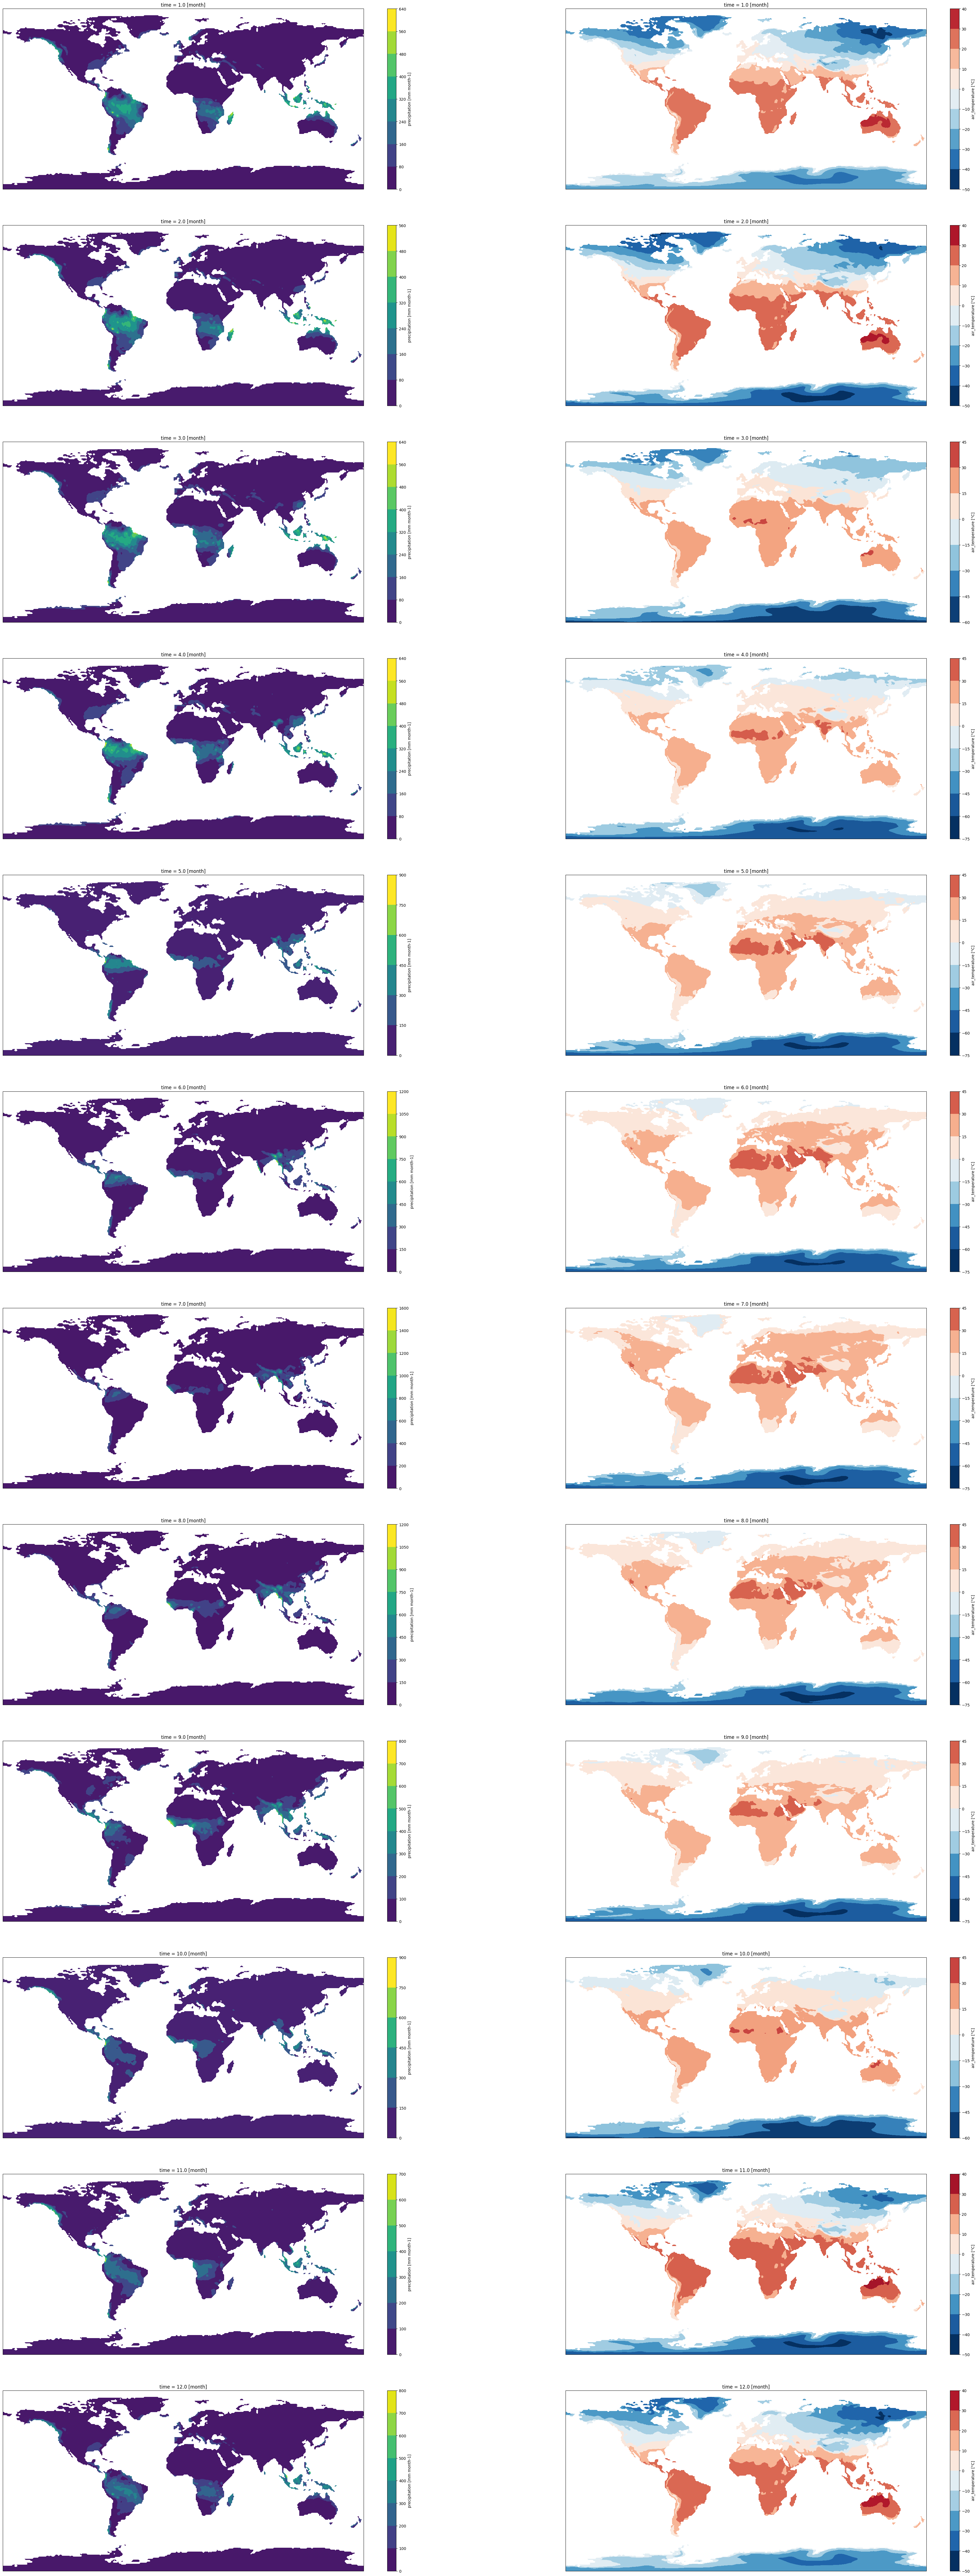

In [28]:
fig1 = matplotlib.pyplot.figure(figsize=(3*16,12*10))

for month in range(12):
    ax1 = fig1.add_subplot(12,2,month*2 +1 ,projection=cartopy.crs.PlateCarree())
    plot_ds = data_dict[select_historic][historic_scenario_str]['climate_mean'].loc[{'time': month+1}]['precipitation']
    plot_ds.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree()) 

    ax1 = fig1.add_subplot(12,2,month*2 +2 ,projection=cartopy.crs.PlateCarree())
    plot_ds = data_dict[select_historic][historic_scenario_str]['climate_mean'].loc[{'time': month+1}]['air_temperature']
    plot_ds.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree()) 


Since the climate zones represent groupings of similar climates, we we want to develop a mapping from the climate means and standard deviations, to the climate classification. We can experiment with different combinations of inputs to see which climate features are most important for determining climate classifications. In addition we can make the problem slightly simpler by focussing on a smaller group of classes, of wich there are only 5, rather than the full 30 subgroups on the full classification scheme.

## Load tabular data

To effectively train a machine learning, we require a substantial number of examples for the algorithm to learn the relationship between the features and the target outcome. If we were to use the entire climate zones map, we would only have a limited number of examples, just 19 across all time periods, which is insufficient for robust learning. Instead we make predictions for each individual land point in the dataset. In addtion, rather than working directly with the gridded data, we have converted it into a tabular dataset (refer to the Data Prep notebook for further details on this process). In this format, each row refers to a different point defined by spatial location and time period, while the columns correspond to various climate attributes and the associated climate zone for each point.

Data preparation for machine learning is a common task. Some datasets need minimal adjustment, while others require extensive cleaning and transformation before they are suitable. The easier it is to use a dat for ML the more "ML-ready" it is. We'll explore this convcept further in the tutorial.

### Load data using pandas

In [29]:
mlready_data_path = ml_ready_dir / ml_ready_fname_template.format(resolution=resolutions_dict[current_res])
print(mlready_data_path.is_file())
mlready_data_path

True


PosixPath('/gws/ssde/j25b/ai4climate/data/climate_zones/ml_ready/climate_zones_1p0.csv')

In [30]:
zones_df = pandas.read_csv(mlready_data_path)

In [31]:
zones_df

,lat,lon,precipitation_1.0_mean,precipitation_2.0_mean,precipitation_3.0_mean,precipitation_4.0_mean,precipitation_5.0_mean,precipitation_6.0_mean,precipitation_7.0_mean,precipitation_8.0_mean,...,air_temperature_10.0_std,air_temperature_11.0_std,air_temperature_12.0_std,kg_class,kg_confidence,period_start,period_end,scenario,climate_group,climate_subgroup
0,83.5,-38.5,12.1250,8.2500,8.9375,21.8750,15.5000,29.8750,35.8750,46.1250,...,2.5625,3.3125,3.6250,29.0,83.0,1901,1930,historic,E,E
1,83.5,-37.5,10.8750,8.1250,8.6250,19.6250,13.8125,26.8750,32.0625,42.0000,...,3.0000,3.8125,4.1250,30.0,86.0,1901,1930,historic,E,E
2,83.5,-36.5,9.9375,8.4375,8.8125,18.1250,12.3750,23.6875,28.5000,37.8125,...,2.5000,3.1875,3.4375,30.0,84.0,1901,1930,historic,E,E
3,83.5,-35.5,10.0000,8.8750,9.0625,17.6250,12.0000,22.4375,26.9375,35.9375,...,2.3750,3.1250,3.4375,30.0,86.0,1901,1930,historic,E,E
4,83.5,-34.5,10.1250,9.1875,9.4375,16.7500,11.3750,20.6250,24.9375,33.3750,...,1.9375,2.5000,2.8750,30.0,76.0,1901,1930,historic,E,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406489,-89.5,175.5,4.0000,4.5625,6.6250,7.0000,7.1875,5.7500,5.6250,8.3125,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406490,-89.5,176.5,4.0000,4.5625,6.6875,7.0625,7.2500,5.8125,5.6250,8.4375,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406491,-89.5,177.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,8.7500,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406492,-89.5,178.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,9.0000,...,1.1250,1.1875,1.4375,30.0,100.0,2071,2099,ssp585,E,E


In [32]:
zones_df.columns

Index(['lat', 'lon', 'precipitation_1.0_mean', 'precipitation_2.0_mean',
       'precipitation_3.0_mean', 'precipitation_4.0_mean',
       'precipitation_5.0_mean', 'precipitation_6.0_mean',
       'precipitation_7.0_mean', 'precipitation_8.0_mean',
       'precipitation_9.0_mean', 'precipitation_10.0_mean',
       'precipitation_11.0_mean', 'precipitation_12.0_mean',
       'air_temperature_1.0_mean', 'air_temperature_2.0_mean',
       'air_temperature_3.0_mean', 'air_temperature_4.0_mean',
       'air_temperature_5.0_mean', 'air_temperature_6.0_mean',
       'air_temperature_7.0_mean', 'air_temperature_8.0_mean',
       'air_temperature_9.0_mean', 'air_temperature_10.0_mean',
       'air_temperature_11.0_mean', 'air_temperature_12.0_mean',
       'precipitation_1.0_std', 'precipitation_2.0_std',
       'precipitation_3.0_std', 'precipitation_4.0_std',
       'precipitation_5.0_std', 'precipitation_6.0_std',
       'precipitation_7.0_std', 'precipitation_8.0_std',
       'precipitatio

### Exploring data distributions
A key part of Exploratory Data Analsyis is to under key atrributes of the data, such as the:
* Range of each feature
* Distribution of values
* Correlations between different variables, especially between predictors and target variables.
* Dataset's coverage or representivity of the dataset, refers to how well it includes the relevant relationships or patterns that a machine learning algorithm must learn.

### Class imbalance - a key machine learning challenge

<Axes: xlabel='climate_subgroup'>

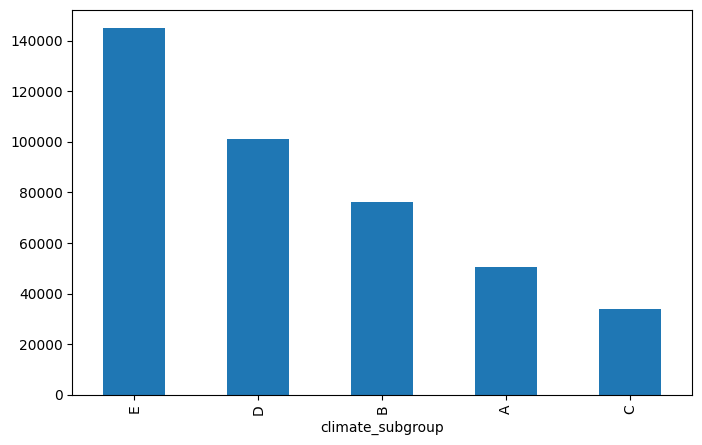

In [33]:
zones_df['climate_subgroup'].value_counts().plot.bar(figsize=(8,5))

We can see from the plot of the number of data points belonging to different climate zones, that this dataset contains what is referred to asa  **class imbalance** . 
In classification problems, like this one, the term class imbalance is defined as follows:

An imbalanced classification problem is an example of a classification problem where the distribution of examples across the known classes is biased or skewed

(taken from article [*A Gentle Introduction to Imbalanced Classification by Jason Brownlee*](https://machinelearningmastery.com/what-is-imbalanced-classification/) )

  Class imbalances can haver many different causes. A common cause in weather in climate relates to rare or extreme events, which have far less representation in most datasetd compared normal weather or climate conditions. In this case the imbalance is caused by how we have represented the world If we di vide up the world by latitude and longitude, then each data point at the equator represents a far smaller amount of surface are of the planet than for poits close to the poles, because the circumference covered at thigher latitudes is smaller but the same number of points. Hence there are far more land points at high latitudes, which is mostly covered by climate zones D and E, than closer to the equator, where climate zones A and B dominate. 

In the plot we see there is not an approximately equal fraction of the data that belongs to the different target classes (i.e. climate zoneas). This poses a challenge for machine learning as the loss function, which guides the iterative updating of parameters during training, is calculated on the entire dataset. If there is a smaller number of points in one class, errors for that class will have a smaller impact on overall performance. For underrepresented classes, an algorithm can often get better scores by just "ignoring" the class altogether. This is a problem in weather and climate where extreme events are the most interesting data points, but also tend to underepresented in the training data due to rarity. Our requirements typically assign greater significance to losses associated with data points that reflect extreme events to be of greater importance than other datapoints representing weather conditions closer to climatological values. So where we identify a class imbalance in a dataset, we need to consider different aspects of our machine learning training pipeline including:
* Correlations between predictors and target variables
* Train/validate/test split
* Selection of metrics
* Analysis of predictions and errors for different classes

### Correlations between predictors and target variables
In order for a machine learning algorithm to be able to learn a mapping from our predictors (in this case monthly means and standard deivations of temperature and preciptation for particular land points on earth) to our target values (categorical classification of the climate zzone for particular land points on earth), we need there to be some pattern in the relationship between the predictors and the target that can be learned by the algorithm. If the distribution of predictors is the sdame for each of the different classes, then there is no pattern that can be used to distinguish between the different classes. So before we start applying machine learning, it is important to explore whether it is reasonable to expect the algorithm to learn a relationship between predictors and targets. 

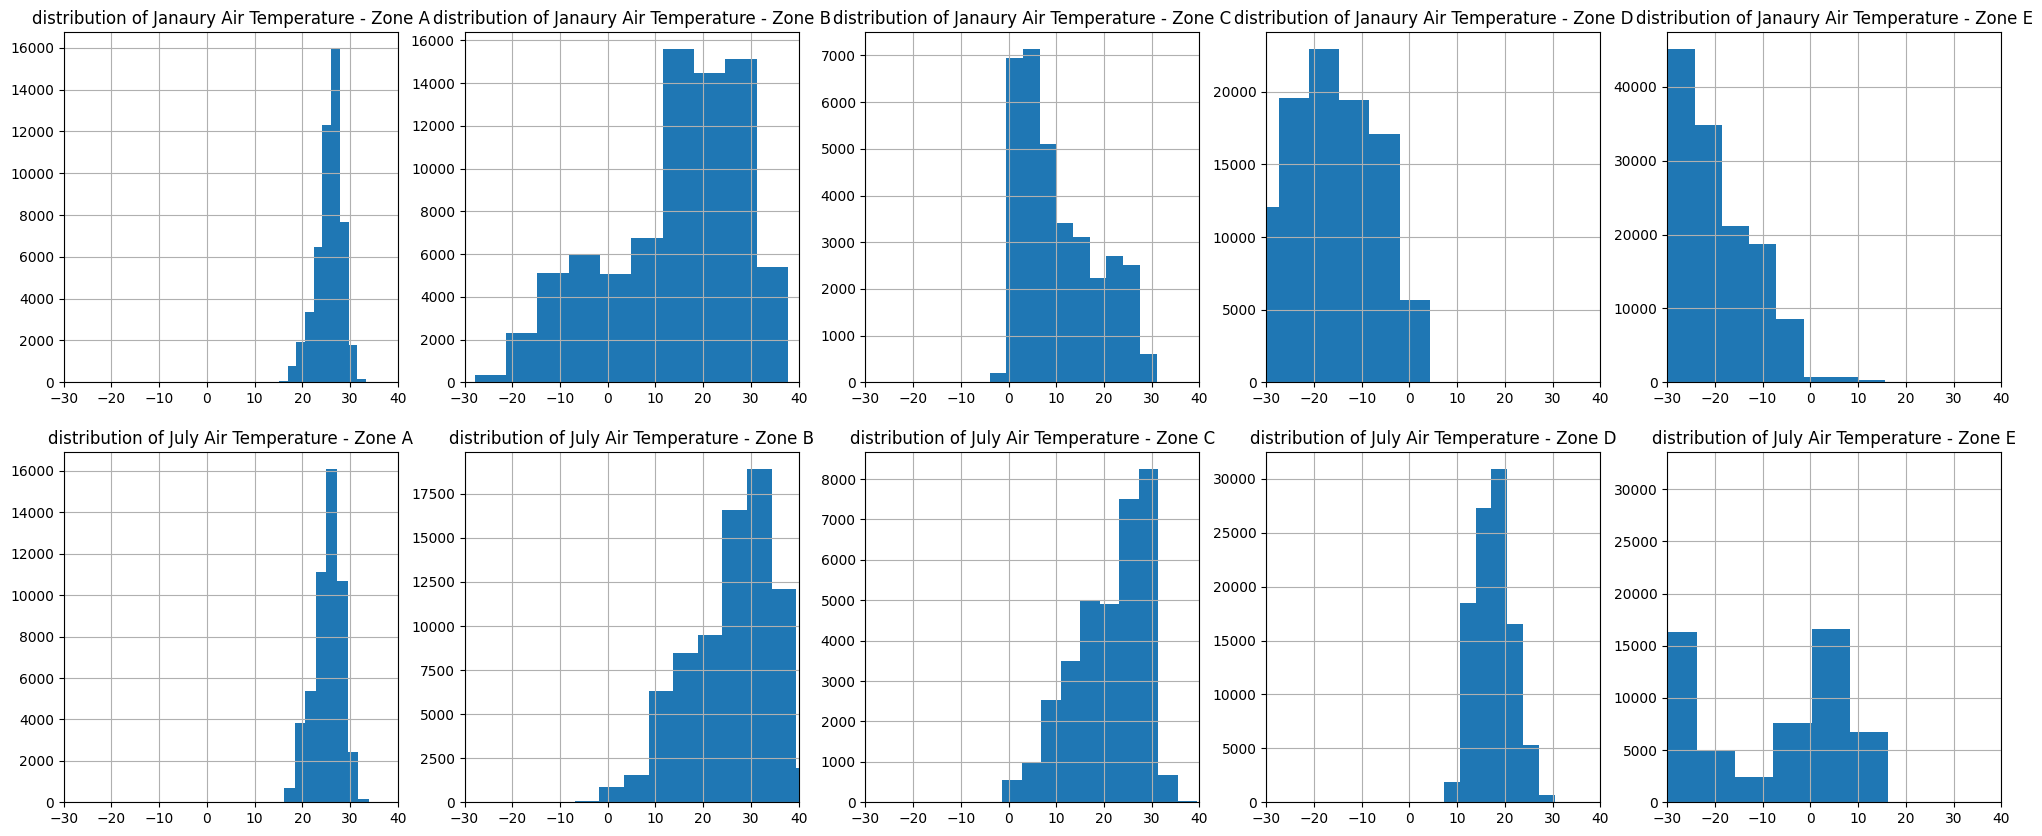

In [34]:
fig1 = matplotlib.pyplot.figure(figsize=(25,10))
for ix_zone, zone_id in enumerate(['A','B','C','D','E']):
    ax1 = fig1.add_subplot(2,5,ix_zone+1, title=f'distribution of Janaury Air Temperature - Zone {zone_id}')
    zones_df[zones_df['climate_group'] == zone_id]['air_temperature_1.0_mean'].hist()
    ax1.set_xlim(-30,40)
    ax1 = fig1.add_subplot(2,5,ix_zone+6, title=f'distribution of July Air Temperature - Zone {zone_id}')
    zones_df[zones_df['climate_group'] == zone_id]['air_temperature_7.0_mean'].hist()
    ax1.set_xlim(-30,40)    
                           

## Exercises
We've only just scratched the surface in terms of exploring the data that we will be using for training a machine learning model.

### Explore distributions for tieme periods and scenarios
How do the climate variable distributions look different for different time periods (historical abd future) and for different climate change scenarios for the future time periods?


In [35]:
# Insert Code

### Further Exploration of Correlations
What can we learn from looking at further correlations between predictors and targets? Are there correlations between some of the predictors, could we further reduce the number of predictors in some way to reduce the cost of training?

In [36]:
# Insert Code

## Next steps and follow on material
- Fu9rther examples of how to work with weather and climate data - [Copernicus Climate Data Store tutorials](https://ecmwf-projects.github.io/copernicus-training-c3s/intro.html)
- Understanding how to prepare data for use with AI/ML [AI Data Readiness](https://github.com/MetOffice/ai_data_readiness)

### Data statement
This data used in this notebook is derived from the Koppen-Geiger Climate Cliassfication dataset created by GloH2O.

###     References
- [Climate Zones Dataset](https://www.gloh2o.org/koppen/#:~:text=The%20K%C3%B6ppen%2DGeiger%20climate%20classification%20maps%20are%20high%2Dresolution,Climate%20Sensitivity%20(ECS)%2C%20and%20historical%20warming%20trend)